In [1]:
import numpy as np
from scipy import sparse
import sys
import os
import matplotlib.pyplot as plt

np.set_printoptions(threshold=np.inf, linewidth=np.inf)

# Absolute path to the folder that contains "quant_rotor"
sys.path.append("/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems")

# One and two body operators
from quant_rotor.Hamiltonian_models.Dense.operators import heisenberg_operators, rotor_operators

# Hamiltonian Constructor
from quant_rotor.Hamiltonian_models.Dense.hamiltonian import hamiltonian_dense

# Basis Changes
from quant_rotor.Hamiltonian_models.Dense.basis_transform import NO_transform, combine_transform ,TF_transform ,energy_transform

# Exact T-amplitude and energy calculations
from quant_rotor.CCC_iterative_methods.Dense.t_amplitudes_exact import t_1_amplitude_guess_ground_state, t_2_amplitude_guess_ground_state, amplitute_energy

# Iterative CCC
from quant_rotor.CCC_iterative_methods.Dense.t_amplitudes_periodic import t_periodic

# Integrator
from quant_rotor.CCC_integration_methods.Dense.de_solve_one_thermal import integration_scheme
from quant_rotor.CCC_integration_methods.Dense.de_solve_one_thermal_dense import integration_scheme as integration_scheme_fast
from quant_rotor.CCC_integration_methods.Dense.stat_mech_thermo import U as U_stat
from quant_rotor.CCC_integration_methods.Dense.stat_mech_thermo import Z as Z_stat
from quant_rotor.CCC_integration_methods.Dense.stat_mech_thermo import S as S_stat
from quant_rotor.CCC_integration_methods.Dense.stat_mech_thermo import A as A_stat
from quant_rotor.CCC_integration_methods.Dense.stat_mech_thermo import Z_new, A_new, S_new

# Rotor Hamiltonian

### Regular Hamiltonian

In [14]:
state = 5
site = 3

g = 0.1
periodic = False

In [15]:
K_rot, V_rot = rotor_operators(state, g)
H_rot = hamiltonian_dense(site, K_rot, V_rot, V_rot, periodic)

In [16]:
eig_val_rot, eig_vec_rot = np.linalg.eigh(H_rot)

### NO hamiltonian transformation

In [17]:
state_NO = 3

In [18]:
K_rot_NO, V_rot_NO, _, _  = NO_transform(state_NO, H_rot, K_rot, V_rot, V_rot)
H_rot_NO = hamiltonian_dense(site, K_rot_NO, V_rot_NO, V_rot_NO, periodic)

[9.79869061e-08 1.53696443e-07 6.17039079e-04 2.51798238e-03 9.96864727e-01]


In [19]:
eig_val_rot_NO, eig_vec_rot_NO = np.linalg.eigh(H_rot_NO)

### Check The Output

In [20]:
print(eig_val_rot)
print(eig_val_rot_NO)

[-0.01250234  0.85082116  0.92329852  0.99343747  0.99718672  1.06452491  1.13325748  1.85690621  1.88229472  1.88536549  1.9271026   1.99378308  1.99560428  1.99681348  1.998667    2.06801019  2.10572829  2.10896896  2.1391426   2.98915964  2.98916122  2.99402439  2.99403545  2.9958433   2.99585365  3.00434502  3.00434537  3.9951302   3.9957014   3.99688618  3.99688836  4.00739967  4.00798604  4.88200435  4.88274966  4.8857497   4.88665241  4.92965644  4.93104337  4.93140582  4.93237262  4.99860824  4.99923896  4.99961698  4.99998932  5.00169041  5.00379803  5.00422345  5.00694005  5.06914345  5.07055917  5.0706991   5.07193548  5.11758518  5.11838198  5.12123035  5.12209402  5.89023096  5.89023279  5.92188669  5.92189066  5.92190384  5.9219193   5.96747141  5.96752804  5.99527164  5.99546594  5.99731769  5.99742987  5.99838202  5.99857142  6.00275474  6.00285941  6.03807562  6.03813012  6.08003572  6.0800647   6.08006963  6.0800736   6.1020711   6.1020735   8.00025533  8.00046753  8.

### Combined Hamiltonian transformation

In [21]:
site_original = 4
site_combined = 2

state = 3 # We reduce the number of states becasue othervise the system becomes too large.

Construct standard rotor operators.

In [22]:
K_rot, V_rot = rotor_operators(state, g)
H_rot = hamiltonian_dense(site_original, K_rot, V_rot, V_rot, periodic)

In [23]:
eig_val_rot, eig_vec_rot = np.linalg.eigh(H_rot)

Transform to combined basis.

In [26]:
K_rot_comb, V_rot_comb_xy, V_rot_comb_yx =  combine_transform(site_combined, K_rot, V_rot)
H_rot_comb = hamiltonian_dense(site_combined, K_rot_comb, V_rot_comb_xy, V_rot_comb_yx, periodic)

In [27]:
eig_val_rot_comb, eig_vec_rot_comb = np.linalg.eigh(H_rot_comb)

Transform rotor standard basis into NO basis.

In [28]:
K_rot_NO, V_rot_NO, _, _  = NO_transform(state_NO, H_rot, K_rot, V_rot, V_rot)
H_rot_NO = hamiltonian_dense(site_original, K_rot_NO, V_rot_NO, V_rot_NO, periodic)

[6.16440654e-04 2.50323111e-03 9.96880328e-01]


Transform NO rotor operators into combined basis.

In [30]:
K_rot_NO_comb, V_rot_NO_comb_xy, V_rot_NO_comb_yx =  combine_transform(site_combined, K_rot, V_rot)
H_rot_NO_comb = hamiltonian_dense(site_combined, K_rot_NO_comb, V_rot_NO_comb_xy, V_rot_NO_comb_yx, periodic)

In [31]:
eig_val_rot_NO_comb, eig_vec_rot_NO_comb = np.linalg.eigh(H_rot_NO_comb)

## Check the output

In [32]:
print(eig_val_rot)
print(eig_val_rot_NO_comb)
print(eig_val_rot_comb)

[-0.01871957  0.826175    0.91012439  0.93223084  0.95943633  1.02128658  1.05515109  1.0717262   1.14896987  1.77668144  1.82484481  1.82484481  1.88676906  1.89936305  1.90780543  1.90780543  1.94752693  1.99236788  1.99484802  1.99484802  1.99563308  1.99704835  1.99891854  1.99891854  2.00621434  2.04748551  2.08725922  2.08725922  2.09938773  2.11023711  2.16759366  2.16759366  2.22254409  2.84896179  2.8591057   2.85929902  2.87192236  2.87928932  2.88695012  2.88726209  2.92192236  2.92200465  2.94257991  2.95685845  2.95695103  2.96731801  2.96800667  2.9709467   2.97928932  3.02071068  3.03149085  3.03669921  3.03700393  3.04414505  3.04418701  3.06568524  3.07807764  3.08343738  3.11555877  3.11576129  3.12071068  3.12807764  3.15097722  3.15113716  3.17257246  4.          4.          4.          4.          4.          4.00088883  4.00109572  4.00109572  4.00504716  4.00623514  4.00623514  4.00623677  4.00856404  4.01139947  4.01139947  4.01672418]
[-0.01871957  0.826175    

# Heisenberg Hamiltonian

***IMPORTANT for Heisenberg systems the state is always 2.***

In [ ]:
site = 5

J_x = 1
J_y = 1
J_z = 0

h_x = 0
h_y = 0
h_z = -1

g = 0.7

In [ ]:
K_heis, V_heis = heisenberg_operators(J_x, J_y, J_z, h_x, h_y, h_z, g)
H_heis = hamiltonian_dense(site, K_heis, V_heis, V_heis, True)

Then constructing the combined hamiltonian is same as for the rotor systems.

# Iterative CCC

In [2]:
state = 3
state_2 = state**2
site = 6

g = 0.1
periodic = False

In [3]:
K_rot, V_rot = rotor_operators(state, g)
H_rot = hamiltonian_dense(site, K_rot, V_rot, V_rot, periodic)

In [4]:
eig_val_rot, eig_vec_rot = np.linalg.eigh(H_rot)

In [5]:
t_1_exact = t_1_amplitude_guess_ground_state(state, site, eig_vec_rot, eig_val_rot)
t_2_exact = t_2_amplitude_guess_ground_state(state, site, eig_vec_rot, eig_val_rot)

In [6]:
E = amplitute_energy(site, state, periodic, K_rot, V_rot.reshape(state, state, state, state), V_rot.reshape(state, state, state, state), np.copy(t_1_exact), np.copy(t_2_exact))

E should be equal to the ground state energy.

In [7]:
eig_val_rot[0]

np.float64(-0.031208902814104912)

In [8]:
energy_per, T_1_per, T_2_per, R_1_per, R_2_per = t_periodic(site, state, K_rot, V_rot.reshape(state, state, state, state), V_rot.reshape(state, state, state, state), "original", gap=True, gap_site=2, Import_t=True, t_1_import=np.copy(t_1_exact), t_2_import=np.copy(t_2_exact), periodic=True)

original
12


In [9]:
energy, T_1, T_2, R_1, R_2 = t_periodic(site, state, K_rot, V_rot.reshape(state, state, state, state), V_rot.reshape(state, state, state, state), "original", Import_t=True, t_1_import=np.copy(t_1_exact), t_2_import=np.copy(t_2_exact), periodic=False)

original
12


In [10]:
energy_per

np.complex128(-0.03746898958667132+0j)

In [11]:
energy

np.complex128(-0.03121048035338587+0j)

In [9]:
# T_1_linked, T_2_linked, R_1_linked, R_2_linked = t_periodic(site, state, K_rot, V_rot.reshape(state, state, state, state), V_rot.reshape(state, state, state, state), "linked", Import_t=True, t_1_import=np.copy(t_1_exact), t_2_import=np.copy(t_2_exact), periodic=periodic, one_cicle=True)

In [10]:
# T_1_transformed, T_2_transformed, R_1_transformed, R_2_transformed = t_periodic(site, state, K_rot, V_rot.reshape(state, state, state, state), V_rot.reshape(state, state, state, state), "transformed", Import_t=True, t_1_import=np.copy(t_1_exact), t_2_import=np.copy(t_2_exact), periodic=periodic, one_cicle=True)

In [11]:
# print("Connected/Linked R_1:" ,np.max(np.abs(R_1_linked - R_1)))
# print("Connected/Linked R_2:" ,np.max(np.abs(R_2_linked - R_2)), "\n")

# print("Connected/Transformed R_1:" ,np.max(np.abs(R_1_transformed - R_1)))
# print("Connected/Transformed R_2:" ,np.max(np.abs(R_2_transformed - R_2)), "\n")

# print("Linked/Transformed R_1:" ,np.max(np.abs(R_1_transformed - R_1_linked)))
# print("Linked/Transformed R_2:" ,np.max(np.abs(R_2_transformed - R_2_linked)))

In [12]:
time, energy, t_0, _, _ = integration_scheme_fast(site, state, K_rot, V_rot.reshape(state, state, state, state), V_rot.reshape(state, state, state, state), periodic=periodic, t_final=40)

xy
xy
xy
xy
xy
xy
xy
xy
0.0
0.07500000000000001
xy
xy
xy
xy
xy
xy
xy
xy
0.0
0.07499984999999906
xy
xy
xy
xy
xy
xy
xy
xy
0.0
0.0749992109976947
xy
xy
xy
xy
xy
xy
xy
xy
0.0
0.07499881650586045
xy
xy
xy
xy
xy
xy
xy
xy
0.0
0.07499822476575013
xy
xy
xy
xy
xy
xy
xy
xy
0.0
0.07499577537337256
xy
xy
xy
xy
xy
xy
xy
xy
0.0
0.0749950001656214
xy
xy
xy
xy
xy
xy
xy
xy
0.0
0.07499625009316256
xy
xy
xy
xy
xy
xy
xy
xy
0.0
0.07499538475650604
xy
xy
xy
xy
xy
xy
xy
xy
0.0
0.07499023140147974
xy
xy
xy
xy
xy
xy
xy
xy
0.0
0.07499100053660394
xy
xy
xy
xy
xy
xy
xy
xy
0.0
0.07498714395223452
xy
xy
xy
xy
xy
xy
xy
xy
0.0
0.07498500149052752
xy
xy
xy
xy
xy
xy
xy
xy
0.0
0.07498500149052752
xy
xy
xy
xy
xy
xy
xy
xy
0.0
0.07497711303312907
xy
xy
xy
xy
xy
xy
xy
xy
0.0
0.07497316973608895
xy
xy
xy
xy
xy
xy
xy
xy
0.0
0.07496725455453272
xy
xy
xy
xy
xy
xy
xy
xy
0.0
0.07494277425778335
xy
xy
xy
xy
xy
xy
xy
xy
0.0
0.07493502798269304
xy
xy
xy
xy
xy
xy
xy
xy
0.0
0.07494751825597665
xy
xy
xy
xy
xy
xy
xy
xy
0.0
0.074938870923

In [13]:
energy[-1] - eig_val_rot[0]

np.complex128(0j)

/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


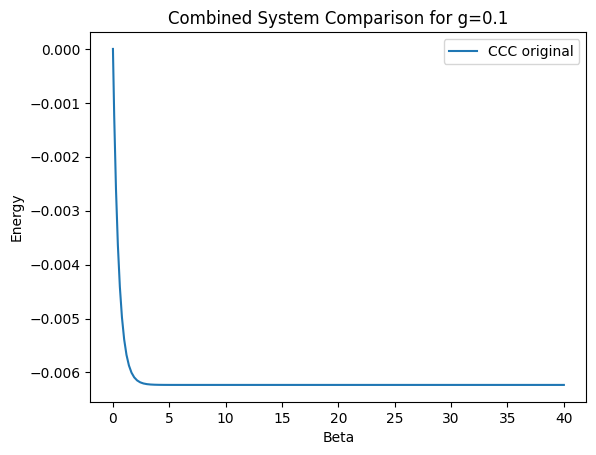

In [14]:
plt.plot(time, energy, label=f"CCC original")
plt.title(f"Combined System Comparison for g={g}")
plt.xlabel("Beta")
plt.ylabel("Energy")
plt.legend()
plt.show()

# TF Integrator

In [172]:
state = 3
state_TF = state**2
site = 2

g = 0.7
periodic = False

In [173]:
K, V = rotor_operators(state, g)
H = hamiltonian_dense(site, K, V, V, periodic)

In [174]:
eig_val, eig_vec = np.linalg.eigh(H)

In [175]:
K_e, V_e, _ = energy_transform(K, V, V)
K_TF, V_TF, _ = TF_transform(K_e, V_e, V_e)

In [176]:
H_TF = hamiltonian_dense(site, K_TF, V_TF, V_TF, periodic)

In [177]:
eig_val_TF, eig_vec_TF = np.linalg.eigh(H_TF)

In [178]:
eig_val_TF

array([-0.26984251, -0.26984251, -0.26984251, -0.26984251, -0.26984251, -0.26984251, -0.26984251, -0.26984251, -0.26984251,  0.3       ,  0.3       ,  0.3       ,  0.3       ,  0.3       ,  0.3       ,  0.3       ,  0.3       ,  0.3       ,  0.65      ,  0.65      ,  0.65      ,  0.65      ,  0.65      ,  0.65      ,  0.65      ,  0.65      ,  0.65      ,  1.35      ,  1.35      ,  1.35      ,  1.35      ,  1.35      ,  1.35      ,  1.35      ,  1.35      ,  1.35      ,  1.7       ,  1.7       ,  1.7       ,  1.7       ,  1.7       ,  1.7       ,  1.7       ,  1.7       ,  1.7       ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.        ,  2.26984251,  2.26984251,  2.26984251,  2.26984251,  2.26

In [179]:
eig_vec_TF[0, :9]

array([ 1.22980026e-35+0.j,  3.49330970e-36+0.j, -3.23500683e-01+0.j, -3.04712514e-32+0.j,  0.00000000e+00+0.j,  8.03642925e-02+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j])

In [180]:
V_TF = V_TF.reshape(state_TF, state_TF, state_TF, state_TF)

In [181]:
i = 1
a = state_TF - i

In [182]:
t_1_tensor = np.zeros((site, a, i), dtype=complex)
t_2_tensor = np.zeros((site, site, a, a, i, i), dtype=complex)

In [183]:
np.log(state**site)

np.float64(2.1972245773362196)

In [184]:
time_TF, energy_TF, t_0_TF, t_1_TF, t_2_TF = integration_scheme_fast(site, state_TF, K_TF, V_TF, V_TF, t_final=40, periodic=periodic, import_guess=True, t_0_import=0, t_1_import=np.copy(t_1_tensor).reshape(site, a), t_2_import=np.copy(t_2_tensor).reshape(site, site, a, a))

0.0
9.999999999999999e-05
0.0011
0.0111
0.1111
0.3069320122580989
0.483981986586735
0.6610319609153712
0.8384573703651695
1.0333703510081094
1.2301693182932436
1.4234573785887863
1.6207379346693838
1.8244458217788224
2.0427897222616367
2.2853819445582753
2.5545065632653134
2.8433792275293124
3.1465574119502815
3.4645580422978
3.797233949868725
4.142841067515279
4.5005731017335675
4.874513079234721
5.283277095048618
5.751885098929715
6.163832330769607
6.572862085759054
6.944186944241177
7.289701269184261
7.6203684745888145
7.941904857790251
8.256654346706474
8.565093254110092
8.86655670876812
9.159628332132973
9.44229027123418
9.712333373953983
9.969410048146722
10.220644419656109
10.476002076537434
10.737388519202876
11.002744565645216
11.269189929246576
11.532748076842921
11.78801955630857
12.03201929963304
12.259283180103793
12.484117185344722
12.708888093970447
12.926401676979404
13.13354703612519
13.35467084954875
13.596613639294963
13.857162276614984
14.13565411294326
14.432701414

In [185]:
# time, energy, t_0_CCC, _, _ = integration_scheme(site, state, K, V.reshape(state, state, state, state), V.reshape(state, state, state, state), periodic=periodic)

## Graphs

In [186]:
ED_U_val = np.array([U_stat(eig_val, x) for x in time_TF])

In [187]:
ED_Z_val = np.array([Z_stat(eig_val, x) for x in time_TF])

In [188]:
def S_new(t_0, beta: float, U_val: float):
    return (U_val * beta + t_0)

In [189]:
S_val = np.array([S_new(t_0_TF[x], time_TF[x], energy_TF[x]) for x in range(1, time_TF.shape[0])])

In [190]:
ED_S_val = np.array([S_stat(eig_val, x) for x in time_TF])

In [191]:
Z_val = np.array([Z_new(x) for x in t_0_TF])

In [192]:
np.max(np.abs(energy_TF - ED_U_val))

np.float64(0.2309102128581647)

In [193]:
ED_U_val - energy_TF

array([-2.22044605e-16+0.j, -2.66453526e-15+0.j, -3.35176331e-12+0.j, -3.41607187e-09+0.j, -3.13442527e-06+0.j, -5.38840220e-05+0.j, -1.73243984e-04+0.j, -3.72024524e-04+0.j, -6.89292271e-04+0.j, -1.29901443e-03+0.j, -2.41394686e-03+0.j, -4.24782155e-03+0.j, -7.08044214e-03+0.j, -1.11298161e-02+0.j, -1.67105560e-02+0.j, -2.42150858e-02+0.j, -3.37444668e-02+0.j, -4.48319053e-02+0.j, -5.68483982e-02+0.j, -6.93728837e-02+0.j, -8.20281827e-02+0.j, -9.44868518e-02+0.j, -1.06580219e-01+0.j, -1.18394744e-01+0.j, -1.30475824e-01+0.j, -1.43477700e-01+0.j, -1.54350000e-01+0.j, -1.64768796e-01+0.j, -1.73973280e-01+0.j, -1.82341846e-01+0.j, -1.90157714e-01+0.j, -1.97529797e-01+0.j, -2.04452030e-01+0.j, -2.10846886e-01+0.j, -2.16590768e-01+0.j, -2.21535658e-01+0.j, -2.25531704e-01+0.j, -2.28457857e-01+0.j, -2.30256247e-01+0.j, -2.30910213e-01+0.j, -2.30280660e-01+0.j, -2.28106081e-01+0.j, -2.24148321e-01+0.j, -2.18269999e-01+0.j, -2.10510589e-01+0.j, -2.01162277e-01+0.j, -1.90626857e-01+0.j, -1.795

In [194]:
energy_TF[-1] - energy_TF[-2]

np.complex128(-0.00013272777399886415+0j)

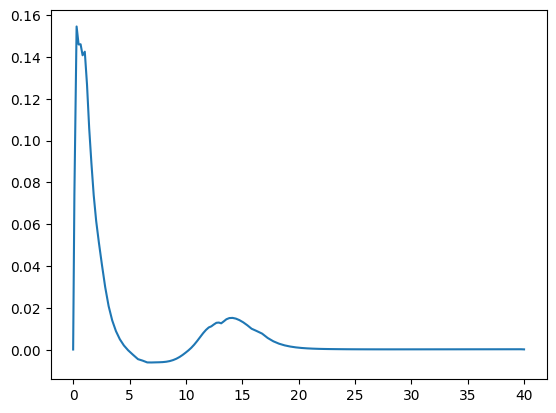

In [195]:
plt.plot(time_TF[1:], energy_TF[:-1] - energy_TF[1:], label=f"TF")
plt.show()

In [196]:
eig_val[0] - energy_TF[-1]

np.complex128(0.03648064806045437+0j)

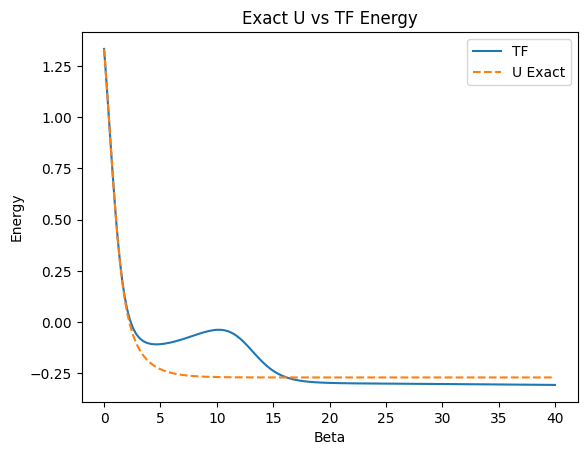

In [197]:
plt.plot(time_TF, energy_TF, label=f"TF")
# plt.plot(time_TF_o, energy_TF_o, label=f"TF")
plt.plot(time_TF, ED_U_val, label=f"U Exact", linestyle="--")
# plt.plot(time, energy, label=f"CCC", linestyle=":")
plt.title("Exact U vs TF Energy")
plt.xlabel("Beta")
plt.ylabel("Energy")
plt.legend()
plt.show()

In [198]:
Z_val

array([1.00000000e+00+0.j, 9.99866679e-01+0.j, 9.98534841e-01+0.j, 9.85352578e-01+0.j, 8.66218748e-01+0.j, 6.88190503e-01+0.j, 5.74083308e-01+0.j, 4.91479769e-01+0.j, 4.31498472e-01+0.j, 3.84521105e-01+0.j, 3.51486289e-01+0.j, 3.29122486e-01+0.j, 3.13741826e-01+0.j, 3.03609737e-01+0.j, 2.97474214e-01+0.j, 2.94802191e-01+0.j, 2.95481368e-01+0.j, 2.99223762e-01+0.j, 3.05522323e-01+0.j, 3.13988180e-01+0.j, 3.24312019e-01+0.j, 3.36187033e-01+0.j, 3.49363995e-01+0.j, 3.63802618e-01+0.j, 3.80065011e-01+0.j, 3.98962403e-01+0.j, 4.15500338e-01+0.j, 4.31592922e-01+0.j, 4.45723917e-01+0.j, 4.58318021e-01+0.j, 4.69760822e-01+0.j, 4.80233688e-01+0.j, 4.89804983e-01+0.j, 4.98502541e-01+0.j, 5.06352184e-01+0.j, 5.13398290e-01+0.j, 5.19709931e-01+0.j, 5.25383681e-01+0.j, 5.30569220e-01+0.j, 5.35560700e-01+0.j, 5.40713898e-01+0.j, 5.46269899e-01+0.j, 5.52444660e-01+0.j, 5.59471793e-01+0.j, 5.67551862e-01+0.j, 5.76767376e-01+0.j, 5.87156308e-01+0.j, 5.98484690e-01+0.j, 6.11503180e-01+0.j, 6.26554868e-0

In [199]:
Z_val - ED_Z_val

array([-8.00000000e+00+0.j, -7.99893343e+00+0.j, -7.98827873e+00+0.j, -7.88282063e+00+0.j, -6.92975068e+00+0.j, -5.50555143e+00+0.j, -4.59278757e+00+0.j, -3.93214956e+00+0.j, -3.45261787e+00+0.j, -3.07738045e+00+0.j, -2.81412133e+00+0.j, -2.63693749e+00+0.j, -2.51681995e+00+0.j, -2.44057236e+00+0.j, -2.39937631e+00+0.j, -2.39105793e+00+0.j, -2.41758174e+00+0.j, -2.47951953e+00+0.j, -2.57577378e+00+0.j, -2.70719743e+00+0.j, -2.87584521e+00+0.j, -3.08396727e+00+0.j, -3.33508349e+00+0.j, -3.63784470e+00+0.j, -4.01872044e+00+0.j, -4.52479707e+00+0.j, -5.03685850e+00+0.j, -5.61396218e+00+0.j, -6.20309176e+00+0.j, -6.81246370e+00+0.j, -7.45598628e+00+0.j, -8.14334782e+00+0.j, -8.88012542e+00+0.j, -9.66868609e+00+0.j, -1.05083664e+01+0.j, -1.13953193e+01+0.j, -1.23219451e+01+0.j, -1.32774278e+01+0.j, -1.42554018e+01+0.j, -1.52800537e+01+0.j, -1.63960681e+01+0.j, -1.76215921e+01+0.j, -1.89577893e+01+0.j, -2.03994114e+01+0.j, -2.19309472e+01+0.j, -2.35214376e+01+0.j, -2.51469723e+01+0.j, -2.675

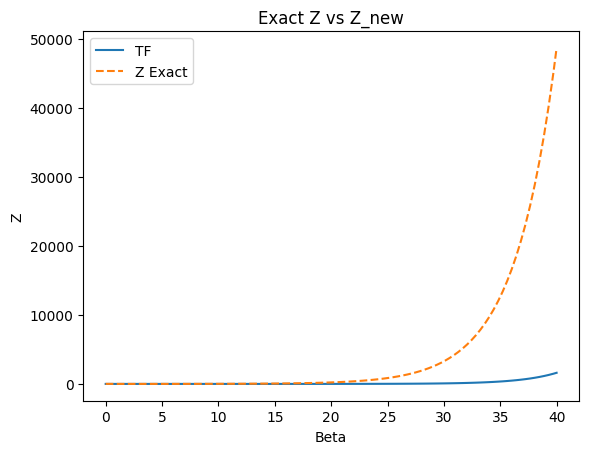

In [200]:
plt.plot(time_TF, Z_val, label=f"TF")
plt.plot(time_TF, ED_Z_val, label=f"Z Exact", linestyle="--")
plt.title("Exact Z vs Z_new")
plt.xlabel("Beta")
plt.ylabel("Z")
plt.legend()
plt.show()

In [201]:
np.max(np.abs(S_val - ED_S_val[1:]))

np.float64(4.86587852611847)

In [202]:
S_val

array([-3.58347345e-09+0.j, -4.33769743e-07+0.j, -4.43408948e-05+0.j, -4.60429172e-03+0.j, -3.70812561e-02+0.j, -9.48485704e-02+0.j, -1.78426984e-01+0.j, -2.83854196e-01+0.j, -4.16979574e-01+0.j, -5.60142746e-01+0.j, -7.00320098e-01+0.j, -8.35803127e-01+0.j, -9.62752437e-01+0.j, -1.08147962e+00+0.j, -1.19184877e+00+0.j, -1.28973284e+00+0.j, -1.37018315e+00+0.j, -1.43241820e+00+0.j, -1.47855938e+00+0.j, -1.51060789e+00+0.j, -1.53023540e+00+0.j, -1.53889290e+00+0.j, -1.53754059e+00+0.j, -1.52573742e+00+0.j, -1.50060655e+00+0.j, -1.46930246e+00+0.j, -1.43042608e+00+0.j, -1.38898500e+00+0.j, -1.34573621e+00+0.j, -1.30075688e+00+0.j, -1.25444822e+00+0.j, -1.20767063e+00+0.j, -1.16171674e+00+0.j, -1.11826109e+00+0.j, -1.07925524e+00+0.j, -1.04675527e+00+0.j, -1.02263001e+00+0.j, -1.00819845e+00+0.j, -1.00441885e+00+0.j, -1.01347336e+00+0.j, -1.03883595e+00+0.j, -1.08391370e+00+0.j, -1.15119248e+00+0.j, -1.24123904e+00+0.j, -1.35159197e+00+0.j, -1.47820554e+00+0.j, -1.61374527e+00+0.j, -1.762

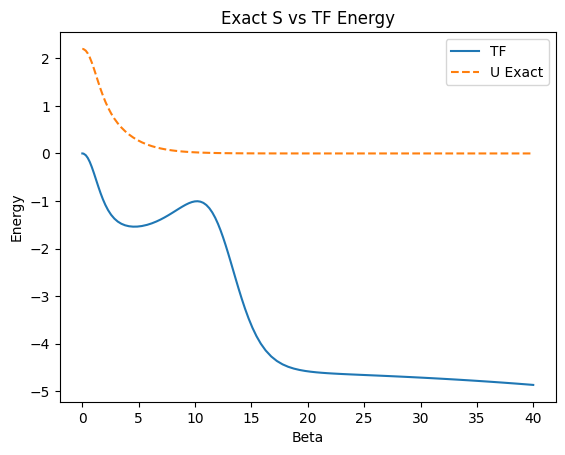

In [203]:
plt.plot(time_TF[1:], S_val, label=f"TF")
plt.plot(time_TF, ED_S_val, label=f"U Exact", linestyle="--")
plt.title("Exact S vs TF Energy")
plt.xlabel("Beta")
plt.ylabel("Energy")
plt.legend()
plt.show()

# Prepare the graph wrapper

Example of the input.

In [2]:
g_range_array = np.array([0.2,])
psi_twist_array = np.array([np.pi/4])
site_array = np.array([3])

In [3]:
def graph_func(g_range_array, psi_twist_array, site_array, ED: bool=True, CCC: bool=True, TF: bool=True):

    state = 7
    state_NO = 5
    state_TF = state_NO**2

    periodic = True

    i = 1
    a = state_TF - i

    CCC_vals_psi = []
    TF_vals_psi = []
    ED_stat_psi = []
    TF_stat_psi = []

    CCC_vals_g_psi = []
    TF_vals_g_psi = []
    ED_stat_g_psi = []
    TF_stat_g_psi = []

    CCC_vals_site_g_psi = []
    TF_vals_site_g_psi = []
    ED_stat_site_g_psi = []
    TF_stat_site_g_psi = []

    for site_idx in range(site_array.shape[0]):

        site = site_array[site_idx]

        t_a_i_tensor = np.zeros((site, a), dtype=complex)
        t_ab_ij_tensor = np.zeros((site, site, a, a), dtype=complex)
        for g_idx in range(g_range_array.shape[0]):
            for psi_twist_idx in range(psi_twist_array.shape[0]):

                g = g_range_array[g_idx]
                psi_twist = psi_twist_array[psi_twist_idx]

                if ED:
                    K, V = rotor_operators(state, g, psi_twist)
                    H = hamiltonian_dense(site, K, V, V, periodic)

                    K_rot_NO, V_rot_NO, _, _  = NO_transform(state_NO, H, K, V, V)
                    H_rot_NO = hamiltonian_dense(site, K_rot_NO, V_rot_NO, V_rot_NO, periodic)

                    eig_val, eig_vec = np.linalg.eigh(H_rot_NO)

                    print("ED Done.")

                if TF:
                    K_e, V_e = rotor_operators(state_NO, g, psi_twist)
                    K_TF, V_TF, _ = TF_transform(K_e, V_e, V_e)

                    time_TF, energy_TF, t_0_TF, _, _ = integration_scheme_fast(site, state_TF, K_TF, V_TF.reshape(state_TF, state_TF, state_TF, state_TF), V_TF.reshape(state_TF, state_TF, state_TF, state_TF), periodic=periodic, import_guess=True, t_0_import=np.log(state**site), t_1_import=t_a_i_tensor, t_2_import=t_ab_ij_tensor)

                    if CCC:
                        time, energy, t_0_CCC, _, _ = integration_scheme(site, state_NO, K_e, V_e.reshape(state_NO, state_NO, state_NO, state_NO), V_e.reshape(state_NO, state_NO, state_NO, state_NO), periodic=periodic)

                    print("TF Done.")

                    ED_U_val = np.array([U_stat(eig_val, x) for x in time_TF])
                    ED_Z_val = np.array([Z_stat(eig_val, x) for x in time_TF])
                    ED_S_val = np.array([S_stat(eig_val, x) for x in time_TF])
                    ED_A_val = np.array([A_stat(eig_val, x) for x in time_TF])


                    S_val = np.array([S_new(t_0_TF[x], time_TF[x], energy_TF[x]) for x in range(1, time_TF.shape[0])])
                    Z_val = np.array([Z_new(x) for x in t_0_TF])
                    A_val = np.array([A_new(t_0_TF[x], time_TF[x]) for x in range(1, time_TF.shape[0])])

                    print("Stat Done.")

                CCC_vals_psi.append((time, energy, t_0_CCC))
                TF_vals_psi.append((time_TF, energy_TF, t_0_CCC))
                ED_stat_psi.append((ED_U_val, ED_Z_val, ED_S_val, ED_A_val))
                TF_stat_psi.append((Z_val, S_val, A_val))

            CCC_vals_g_psi.append(CCC_vals_psi)
            TF_vals_g_psi.append(TF_vals_psi)
            ED_stat_g_psi.append(ED_stat_psi)
            TF_stat_g_psi.append(TF_stat_psi)

        CCC_vals_site_g_psi.append(CCC_vals_g_psi)
        TF_vals_site_g_psi.append(TF_vals_g_psi)
        ED_stat_site_g_psi.append(ED_stat_g_psi)
        TF_stat_site_g_psi.append(TF_stat_g_psi)

    return CCC_vals_site_g_psi, TF_vals_site_g_psi, ED_stat_site_g_psi, TF_stat_site_g_psi

In [4]:
CCC_array, TF_array, ED_stat_array, TF_stat_array = graph_func(g_range_array, psi_twist_array, site_array)

[8.64844368e-11 1.07262384e-10 8.23430057e-07 1.48763753e-06 1.35218317e-03 4.06657931e-03 9.94578926e-01]
ED Done.
0.0
0.0034346068664900926
0.03778067553139102
0.1603879562823955
0.2864523453311471
0.40889304601417054
0.5250372957801889
0.6451316446405664
0.7747025641516393
0.9104894938423213
1.0474882215073442
1.1875479200269412
1.33140265895728
1.4761880864380903
1.6189437224817704
1.7585098543590512
1.8948022335066075
2.0282167404098725
2.1600593421373064
2.293630402134406
2.432561259213046
2.5730658283244208
2.7204726603823084
2.876196369332726
3.0409770248945844
3.2155732020536836
3.4008910484065464
3.5954834872629395
3.799676374087553
4.0150399319175305
4.243316473115265
4.486324334796374
4.74593229180456
5.024756920688579
5.329992186322995
5.679110483079273
6.095535118208159
6.595535118208159
7.095535118208159
7.595535118208159
8.095535118208158
8.595535118208158
9.095535118208158
9.595535118208158
0.0
9.999999999999999e-05
0.0011
0.0111
0.1111
0.46375381238088276
0.8548180862

/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/quant_rotor/CCC_integration_methods/Dense/stat_mech_thermo.py:202: RuntimeWarning: divide by zero encountered in scalar divide
  return float((-1.0 / beta_val) * np.log(Z(eig_val, beta_val)))
/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/quant_rotor/CCC_integration_methods/Dense/stat_mech_thermo.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  return float((-1.0 / beta_val) * np.log(Z_new(t_0)))


Example of how to deal with the output.

CCC_array[first index is associated with the number of sited from site_array][second index is the g value from the g_range][third index is the psi value from the psi range][third index is you are choosing between beta, energy or t_0]

TF_vals_g_psi - same as CCC_array

ED_stat_array[site index][g index][psi index][index from 0-3 U, Z, S, A]

TF_stat_array[site index][g index][psi index][index from 0-2 Z, S, A]

/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


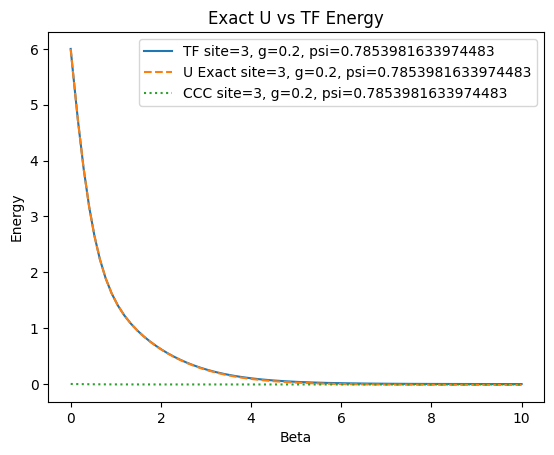

In [5]:
for site_idx in range(site_array.shape[0]):
    for g_idx in range(g_range_array.shape[0]):
        for psi_twist_idx in range(psi_twist_array.shape[0]):
            plt.plot(TF_array[site_idx][g_idx][psi_twist_idx][0], TF_array[site_idx][g_idx][psi_twist_idx][1], label=f"TF site={site_array[site_idx]}, g={g_range_array[g_idx]}, psi={psi_twist_array[psi_twist_idx]}")
            plt.plot(TF_array[site_idx][g_idx][psi_twist_idx][0], ED_stat_array[site_idx][g_idx][psi_twist_idx][0], label=f"U Exact site={site_array[site_idx]}, g={g_range_array[g_idx]}, psi={psi_twist_array[psi_twist_idx]}", linestyle="--")
            plt.plot(CCC_array[site_idx][g_idx][psi_twist_idx][0], CCC_array[site_idx][g_idx][psi_twist_idx][1], label=f"CCC site={site_array[site_idx]}, g={g_range_array[g_idx]}, psi={psi_twist_array[psi_twist_idx]}", linestyle=":")
plt.title("Exact U vs TF Energy")
plt.xlabel("Beta")
plt.ylabel("Energy")
plt.legend()
plt.show()

# Test magnetic Exactness

In [ ]:
site = 2
site_comb = 4

J_x = 1
J_y = 1
J_z = 0

h_x = 0
h_y = 0
h_z = -1

g = 0.8

state_comb = 2**site_comb
periodic = False

In [ ]:
K_heis, V_heis = heisenberg_operators(J_x, J_y, J_z, h_x, h_y, h_z, g)
H_heis = hamiltonian_dense(site*site_comb, K_heis, V_heis, V_heis, periodic)

In [ ]:
K_comb, V_comb_xy, V_comb_yx = combine_transform(site_comb, K_heis ,V_heis)
K_comb, V_comb_xy, V_comb_yx = energy_transform(K_comb, V_comb_xy, V_comb_yx)
H_comb = hamiltonian_dense(site, K_comb, V_comb_xy, V_comb_yx, periodic)

In [ ]:
V_comb_xy = V_comb_xy.reshape(state_comb, state_comb, state_comb ,state_comb)
V_comb_yx = V_comb_yx.reshape(state_comb, state_comb, state_comb ,state_comb)

In [ ]:
eig_val, eig_vec = np.linalg.eigh(H_heis)
eig_val_comb, eig_vec_comb = np.linalg.eigh(H_comb)

In [ ]:
t_1_exact = t_1_amplitude_guess_ground_state(state_comb, site, eig_vec_comb, eig_val_comb)
t_2_exact = t_2_amplitude_guess_ground_state(state_comb, site, eig_vec_comb, eig_val_comb)

In [ ]:
E = amplitute_energy(site, state_comb, periodic, K_comb, V_comb_xy, V_comb_yx, np.copy(t_1_exact), np.copy(t_2_exact))

E should be equal to the ground state energy.

In [ ]:
E - eig_val[0]

In [ ]:
T_1_e, T_2_e, R_1_e, R_2_e = t_periodic(site, state_comb, K_comb, V_comb_xy, V_comb_yx, "original", Import_t=True, t_1_import=np.copy(t_1_exact), t_2_import=np.copy(t_2_exact), periodic=periodic, one_cicle=True)

In [ ]:
print(np.max(np.abs(R_1_e)))
print(np.max(np.abs(R_2_e)))

# Combined Rotor Demonstration

In [80]:
state = 2

site = 6
site_1 = 2
site_2 = 3

state_comb_2 = state**site_1
state_comb_4 = state**site_2

g = 0.3
periodic = False

In [81]:
J_x = 1
J_y = 1
J_z = 0

h_x = 0
h_y = 0
h_z = -1

In [82]:
K, V = heisenberg_operators(J_x, J_y, J_z, h_x, h_y, h_z, g)
# K, V = rotor_operators(state, g)

In [83]:
K_comb_2, V_comb_2_xy, V_comb_2_yx = combine_transform(site_1, K, V)
K_comb_e_2, V_comb_e_2_xy, V_comb_e_2_yx = energy_transform(K_comb_2, V_comb_2_xy, V_comb_2_yx)

In [84]:
K_comb_4, V_comb_4_xy, V_comb_4_yx = combine_transform(site_2, K, V)
K_comb_e_4, V_comb_e_4_xy, V_comb_e_4_yx = energy_transform(K_comb_4, V_comb_4_xy, V_comb_4_yx)

In [85]:
H = hamiltonian_dense(site, K, V, V, periodic)
H_comb_e_2 = hamiltonian_dense(2, K_comb_e_2, V_comb_e_2_xy, V_comb_e_2_yx, periodic)
H_comb_e_4 = hamiltonian_dense(2, K_comb_e_4, V_comb_e_4_xy, V_comb_e_4_yx, periodic)

In [86]:
# H_sparse = sparse.csr_matrix(H)
# eigvals, eigvecs = sparse.linalg.eigsh(H_sparse, k=1, which='SA')

In [87]:
eig_val, eig_vec = np.linalg.eigh(H)
eig_val_comb_e_2, eig_vec_comb_e_2 = np.linalg.eigh(H_comb_e_2)
eig_val_comb_e_4, eig_vec_comb_e_4 = np.linalg.eigh(H_comb_e_4)

In [88]:
V = V.reshape(state, state, state, state)

V_comb_e_2_xy = V_comb_e_2_xy.reshape(state_comb_2, state_comb_2, state_comb_2, state_comb_2)
V_comb_e_2_yx = V_comb_e_2_yx.reshape(state_comb_2, state_comb_2, state_comb_2, state_comb_2)

V_comb_e_4_xy = V_comb_e_4_xy.reshape(state_comb_4, state_comb_4, state_comb_4, state_comb_4)
V_comb_e_4_yx = V_comb_e_4_yx.reshape(state_comb_4, state_comb_4, state_comb_4, state_comb_4)

In [89]:
a = state_comb_4 -1

In [90]:
time, energy, t_0, _, _= integration_scheme_fast(site, state, K, V, V, periodic=periodic, t_final=40)

0.0
1e-06
1.1e-05
0.00011099999999999999
0.001111
0.011111
0.11111099999999997
0.611111
1.111111
1.611111
2.111111
2.611111
3.111111
3.611111
4.111111
4.611111
5.111111
5.611111
6.111111
6.611111
7.111111
7.611111
8.111111000000001
8.611111000000001
9.111111000000001
9.611111000000001
10.111111000000001
10.611111000000001
11.111111000000001
11.611111000000001
12.111111000000001
12.611111000000001
13.111111000000001
13.611111000000001
14.111111000000001
14.611111000000001
15.111111000000001
15.611111000000001
16.111111
16.611111
17.111111
17.611111
18.111111
18.611111
19.111111
19.611111
20.111111
20.611111
21.111111
21.611111
22.111111
22.611111
23.111111
23.611111
24.111111
24.611111
25.111111
25.611111
26.111111
26.611111
27.111111
27.611111
28.111111
28.611111
29.111111
29.611111
30.111111
30.611111
31.111111
31.611111
32.111111
32.611111
33.111111
33.611111
34.111111
34.611111
35.111111
35.611111
36.111111
36.611111
37.111111
37.611111
38.111111
38.611111
39.111111
39.611111


In [91]:
time_2, energy_2, t_0, T_1, T_2 = integration_scheme_fast(2, state_comb_2, K_comb_e_2, V_comb_e_2_xy, V_comb_e_2_yx, periodic=periodic, t_final=40)

0.0
9.999999999999999e-05
0.0011
0.0111
0.1111
0.6111
1.1111
1.6111
2.1111
2.6111
3.1111
3.6111
4.1111
4.6111
5.1111
5.6111
6.1111
6.6111
7.1111
7.6111
8.1111
8.6111
9.1111
9.6111
10.1111
10.6111
11.1111
11.6111
12.1111
12.6111
13.1111
13.6111
14.1111
14.6111
15.1111
15.6111
16.1111
16.6111
17.1111
17.6111
18.1111
18.6111
19.1111
19.6111
20.1111
20.6111
21.1111
21.6111
22.1111
22.6111
23.1111
23.6111
24.1111
24.6111
25.1111
25.6111
26.1111
26.6111
27.1111
27.6111
28.1111
28.6111
29.1111
29.6111
30.1111
30.6111
31.1111
31.6111
32.1111
32.6111
33.1111
33.6111
34.1111
34.6111
35.1111
35.6111
36.1111
36.6111
37.1111
37.6111
38.1111
38.6111
39.1111
39.6111


In [92]:
time_4, energy_4, t_0_4, t_1, t_2 = integration_scheme_fast(2, state_comb_4, K_comb_e_4, V_comb_e_4_xy, V_comb_e_4_yx, periodic=periodic, t_final=40)

0.0
9.999999999999999e-05
0.0011
0.0111
0.1111
0.6111
1.1111
1.6111
2.1111
2.6111
3.1111
3.6111
4.1111
4.6111
5.1111
5.6111
6.1111
6.6111
7.1111
7.6111
8.1111
8.6111
9.1111
9.6111
10.1111
10.6111
11.1111
11.6111
12.1111
12.6111
13.1111
13.6111
14.1111
14.6111
15.1111
15.6111
16.1111
16.6111
17.1111
17.6111
18.1111
18.6111
19.1111
19.6111
20.1111
20.6111
21.1111
21.6111
22.1111
22.6111
23.1111
23.6111
24.1111
24.6111
25.1111
25.6111
26.1111
26.6111
27.1111
27.6111
28.1111
28.6111
29.1111
29.6111
30.1111
30.6111
31.1111
31.6111
32.1111
32.6111
33.1111
33.6111
34.1111
34.6111
35.1111
35.6111
36.1111
36.6111
37.1111
37.6111
38.1111
38.6111
39.1111
39.6111


In [93]:
gs_energy = np.ones((time.shape)) * eig_val[0]

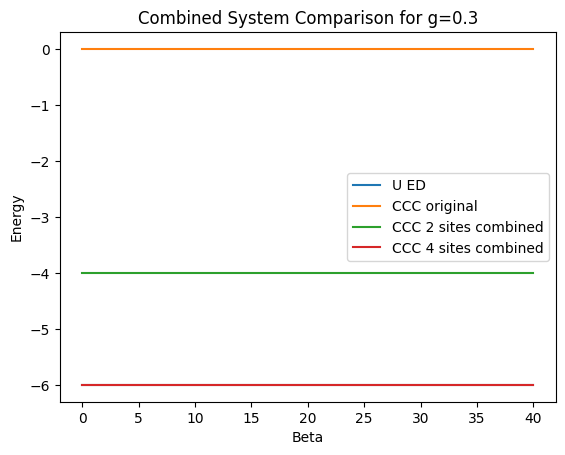

In [94]:
plt.plot(time, gs_energy, label=f"U ED")
plt.plot(time, energy, label=f"CCC original")
plt.plot(time_2, energy_2, label=f"CCC 2 sites combined")
plt.plot(time_4, energy_4, label=f"CCC 4 sites combined")
plt.title(f"Combined System Comparison for g={g}")
plt.xlabel("Beta")
plt.ylabel("Energy")
plt.legend()
plt.show()

In [95]:
shift = 20

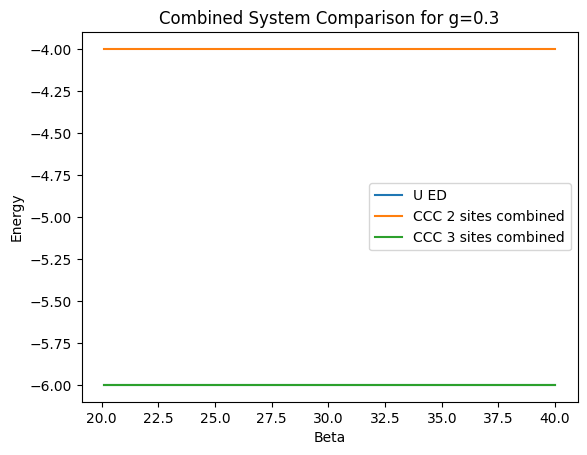

In [96]:
plt.plot(time[time > shift], gs_energy[time > shift], label=f"U ED")
# plt.plot(time[time > shift], energy[time > shift], label=f"CCC original")
plt.plot(time_2[time_2 > shift], energy_2[time_2 > shift], label=f"CCC 2 sites combined")
plt.plot(time_4[time_4 > shift], energy_4[time_4 > shift], label=f"CCC 3 sites combined")
plt.title(f"Combined System Comparison for g={g}")
plt.xlabel("Beta")
plt.ylabel("Energy")
plt.legend()
plt.show()